<a href="https://colab.research.google.com/github/AqsaHerryPrastyo/PCVK/blob/main/Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Tugas 3: Dilasi (Tanpa Library)

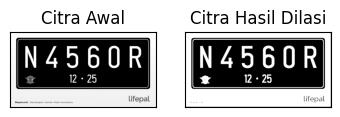

In [5]:
#Dilasi tanpa library
def dilasi_citra(F, w):
    #size image
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    #Generate structure element dilasi (SED)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2
    #Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

img_d = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)

if img_d is None:
    print("Error: Image not loaded. Please check the file path.")
else:
    ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY)
    w = 5
    imgD = dilasi_citra(thresh, w)

    plt.subplot(131), plt.imshow(img_d, cmap='gray')
    plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
    plt.subplot(132), plt.imshow(imgD, cmap='gray')
    plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])
    plt.show()

## Tugas 4: Dilasi (Dengan Library OpenCV)

[[1 1 1]
 [1 1 1]
 [1 1 1]]


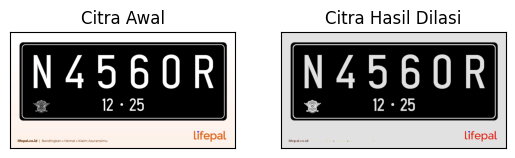

In [6]:
img = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg')
#img = cv2.imread('morp.jpg',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3, 3), np.uint16)
dilasi = cv2.dilate(thresh, kernel, iterations=1)

print(kernel)
plt.subplot(121), plt.imshow(img), plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(dilasi), plt.title('Citra Hasil Dilasi')
plt.xticks([]), plt.yticks([])
plt.show()

## Tugas 5: Erosi (Tanpa Library)

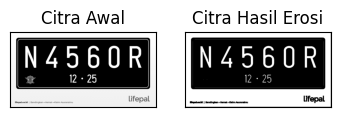

In [9]:
#Erosi Tanpa Library
def erosi_citra(F, k):
    #size image
    m, n = F.shape
    #Generate structure element erosi (SE)
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)
    #Proses Erosi
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

img_e = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
retl, threshl = cv2.threshold(img_e, 175, 225, cv2.THRESH_BINARY)
k = 5
imgE = erosi_citra(threshl, k)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]),
plt.yticks([])
plt.show()

## Tugas 6: Erosi (Dengan Library OpenCV)

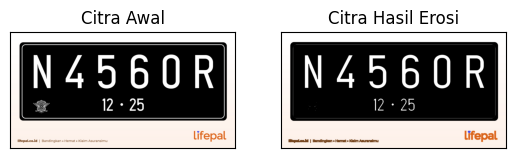

In [10]:
#EROSI LIBRARY
img = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg')
kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(img, kernel, iterations=1)

plt.subplot(121), plt.imshow(img), plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(erosion), plt.title('Citra Hasil Erosi')
plt.xticks([]), plt.yticks([])
plt.show()

## Tugas 7: Operasi Opening

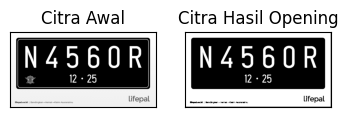

In [11]:
#Operasi Opening Menggunakan tanpa Library Morphology
img_o = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
reto, thresho = cv2.threshold(img_o, 127, 225, cv2.THRESH_BINARY)
k = 7
imgo = dilasi_citra(erosi_citra(thresho, k), k)

plt.subplot(131), plt.imshow(img_o, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgo, cmap='gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])
plt.show()

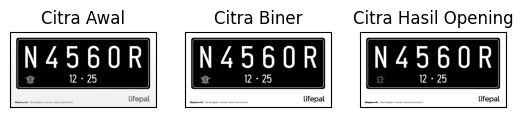

In [12]:
#Operasi Opening Menggunakan Library Morphology
#Dengan Menggunakan Library
img = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3, 3), np.uint8)
openn = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(thresh, cmap='gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(openn, cmap='gray')
plt.title('Citra Hasil Opening'), plt.xticks([]),
plt.yticks([])
plt.show()

## Tugas 8: Operasi Closing

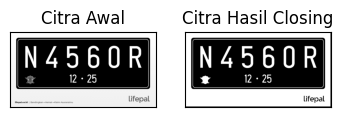

In [13]:
#operasi closing tanpa library morphology
img_c = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
retc, threshc = cv2.threshold(img_c, 127, 225, cv2.THRESH_BINARY)
k = 7
imgC = erosi_citra(dilasi_citra(threshc, k), k)

plt.subplot(131), plt.imshow(img_c, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgC, cmap='gray')
plt.title('Citra Hasil Closing'), plt.xticks([]),
plt.yticks([])
plt.show()

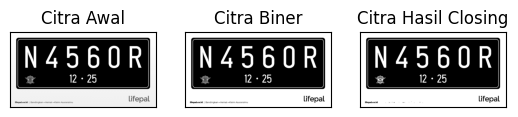

In [14]:
#operasi closing dengan library morphology
img = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3, 3), np.uint8)
closs = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(thresh, cmap='gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(closs, cmap='gray')
plt.title('Citra Hasil Closing'), plt.xticks([]), plt.yticks([])
plt.show()

## Tugas 9: Dilasi (Structuring Element Cross)

SED Cross 3


<function matplotlib.pyplot.show(close=None, block=None)>

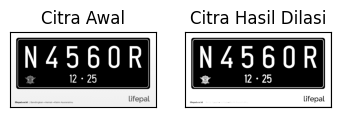

In [15]:
#Dilasi Cross SED
def dilasi_citra(F, w):
    #size image
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    #Generate structure element dilasi (SED)
    #SED= np.ones((w,w), dtype np.uint8)
    SED = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype=np.uint8)
    constant1 = (w - 1) // 2
    #Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

print('SED Cross 3')
img_d = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]),
plt.yticks([])
plt.show

SED Cross 5


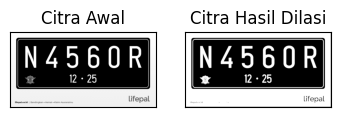

In [16]:
def dilasi_citra(F, w):
    #size image
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    #Generate structure element dilasi (SED)
    #SED= np.ones((w,w), dtype=np.uint8)
    SED = np.array([[0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0],
                    [1, 1, 1, 1, 1],
                    [0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)
    constant1 = (w - 1) // 2
    #Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

print('SED Cross 5')
img_d = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]),
plt.yticks([])
plt.show()

## Tugas 10: Dilasi (Structuring Element Circular)

SED Circle 3


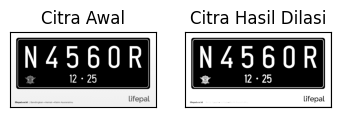

In [17]:
#Dilasi Circular SED
def dilasi_citra(F, w):
    #size image
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    #Generate structure element dilasi (SED)
    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))
    constant1 = (w - 1) // 2
    #Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

print('SED Circle 3')
img_d = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]),
plt.yticks([])
plt.show()

SED Circle 5


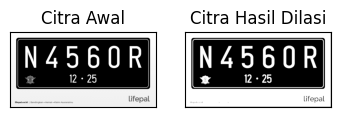

In [18]:
print('SED Circle 5')
img_d = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]),
plt.yticks([])
plt.show()

## Tugas 11: Erosi (Structuring Element Rectangle)

SE Rectangle 3x5


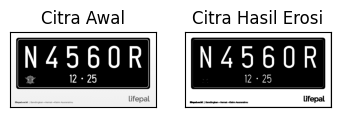

In [20]:
#Erosi Cross SE
def erosi_citra(F, p, l):
    #size image
    m, n = F.shape
    #Generate structure element erosi (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l)) #SE persegi panjang
    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2
    #print(SE)
    imgE = np.zeros((m, n), dtype=np.uint8)
    #Proses Erosi
    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i - constant1:i + constant1 + 1, j - constant2:j + constant2 + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

print('SE Rectangle 3x5')
img_e = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
retl, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p = 5
l = 3
imgE = erosi_citra(thresh1, p, l)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])
plt.show()

SE Rectangle 5x7


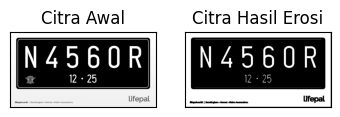

In [21]:
print('SE Rectangle 5x7')
img_e = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)
retl, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p = 7
l = 5
imgE = erosi_citra(thresh1, p, l)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])
plt.show()

## Tugas 12: Erosi (Structuring Element Line Vertikal)

SE Line Vertikal 3


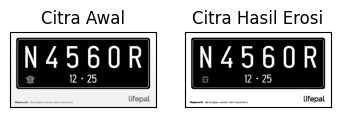

In [23]:
#Erosi Line Vertikal SE menggunakan Library OpenCV
print('SE Line Vertikal 3')
img_e = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)

if img_e is None:
    print("Error: Image not loaded. Please check the file path.")
else:
    retl, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
    k = 3
    # Generate SE line vertikal using OpenCV
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, k))
    # Perform erosion using OpenCV
    imgE = cv2.erode(thresh1, kernel, iterations=1)

    plt.subplot(131), plt.imshow(img_e, cmap='gray')
    plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
    plt.subplot(132), plt.imshow(imgE, cmap='gray')
    plt.title('Citra Hasil Erosi'), plt.xticks([]),
    plt.yticks([])
    plt.show()

SE Line Vertikal 5


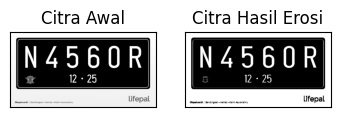

In [25]:
print('SE Line Vertikal 5')
img_e = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg', 0)

if img_e is None:
    print("Error: Image not loaded. Please check the file path.")
else:
    retl, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
    k = 5
    # Generate SE line vertikal using OpenCV
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, k))
    # Perform erosion using OpenCV
    imgE = cv2.erode(thresh1, kernel, iterations=1)

    plt.subplot(131), plt.imshow(img_e, cmap='gray')
    plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
    plt.subplot(132), plt.imshow(imgE, cmap='gray')
    plt.title('Citra Hasil Erosi'), plt.xticks([]),
    plt.yticks([])
    plt.show()

## Tugas 13: Top-Hat

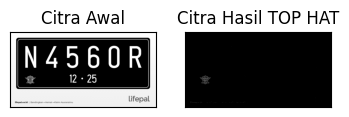

In [26]:
#13 TopHat
#Getting the kernel to be used in Top-Hat
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)
# Reading the image named 'input.jpg'
img = cv2.imread('/content/drive/MyDrive/Image/platnomer.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Applying the Top-Hat operation
# Baris asli: tophat_img = cv2.morphologyEx(input_image,
# Variabel input_image tidak ada, diganti img
tophat_img = cv2.morphologyEx(img,
                              cv2.MORPH_TOPHAT,
                              kernel)
#cv2.imshow("original", input_image)
#cv2.imshow("tophat", tophat_img)
#cv2.waitKey(5000)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(tophat_img, cmap='gray')
plt.title('Citra Hasil TOP HAT'), plt.xticks([]), plt.yticks([])
plt.show()

## Tugas 14: Black-Hat

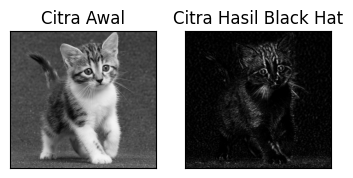

In [27]:
#14 BLACKHAT
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)
#Reading the image named 'input.jpg'
img = cv2.imread('/content/drive/MyDrive/Image/kitten01.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Applying the Black-Hat operation
#tophat_img = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)
Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, Kernel)

#cv2.imshow("original", input_image)
#cv2.imshow("tophat", tophat_img)
#cv2.waitKey(5000)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(blackhat, cmap='gray')
plt.title('Citra Hasil Black Hat'), plt.xticks([]), plt.yticks([])
plt.show()

## Tugas 15: Skeleton

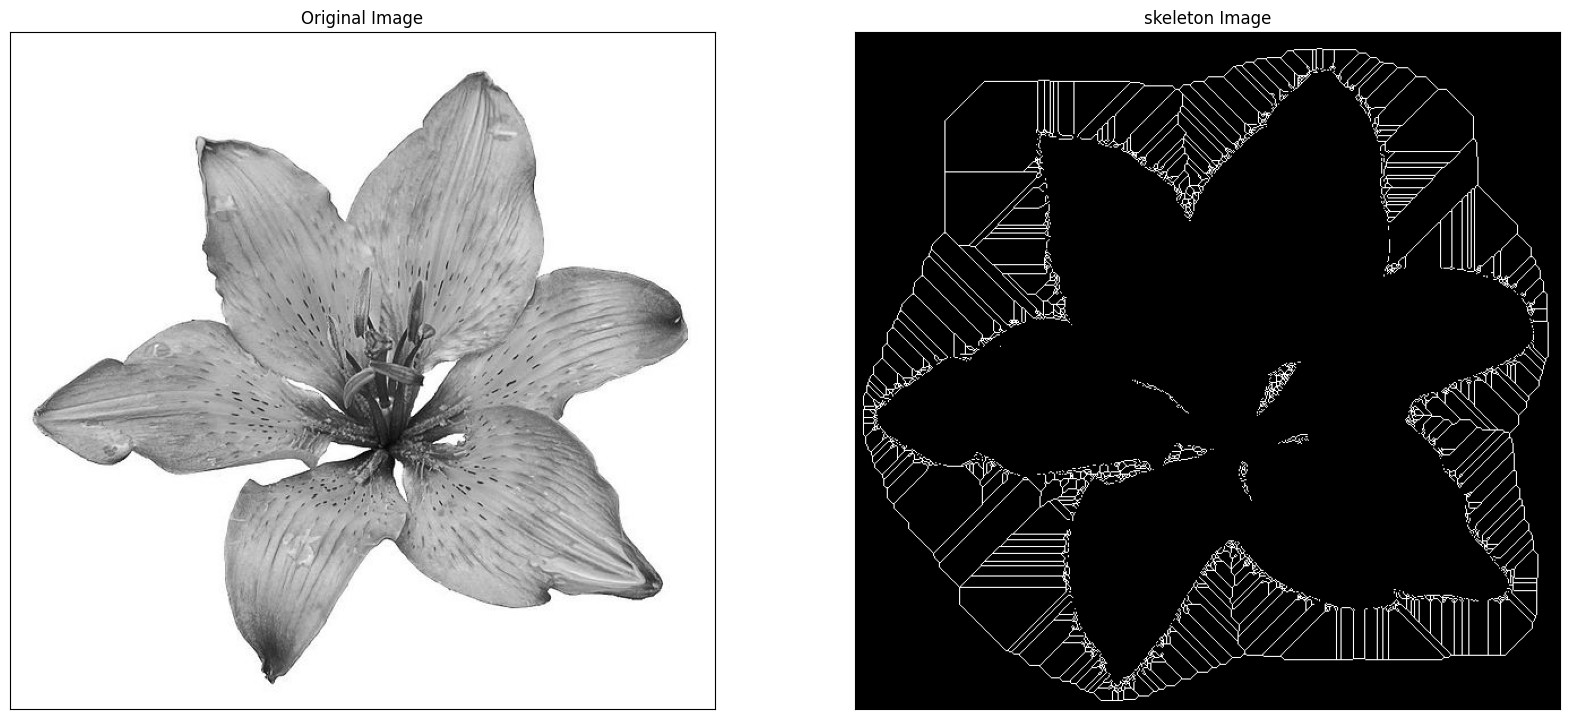

In [28]:
#15. Skeleton
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

#read image
img = cv.imread('/content/drive/MyDrive/Image/lily.jpg', 0)
# Baris asli[cite: 928]: binary img > filters.threshold triangle (img)
# Ini adalah perbandingan, kita perbaiki
binary = img > filters.threshold_triangle(img)
#true false to one
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0
# skeletonize image
skeleton = skeletonize(binary_cp)
#print images
plt.figure(figsize=(20, 20))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(skeleton, cmap='gray')
plt.title('skeleton Image'), plt.xticks([]), plt.yticks([])
plt.savefig("binary and bin skeleton.png")
plt.show()

## Tugas 16: Skeleton Inverse

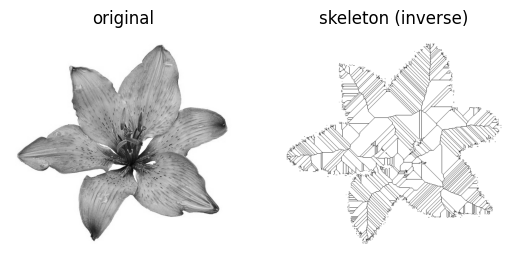

In [29]:
#16. Skeleton Inverse
from skimage import io
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

#read image
# Baris asli :
# img = io.imread('/content/drive/MyDrive/PCVK/Images/lily.jpg')[.... 0]
# Kita perbaiki agar bisa dibaca sebagai grayscale
img = io.imread('/content/drive/MyDrive/Image/lily.jpg', as_gray=True)

#Note: we want the black bits to be True, so use <
binary = img < filters.threshold_triangle(img)
#skeletonize image
skeleton = skeletonize(binary)
# print images
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray')
ax[0].set_title('original')
ax[0].set_axis_off()
#note the reversed colormap, gray_r
ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('skeleton (inverse)')
ax[1].set_axis_off()
plt.show()

## Tugas 17: Thickening (Thinning)

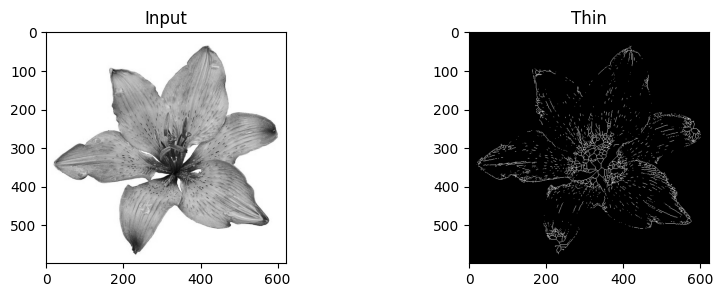

In [30]:
#17. Thickening
from skimage import img_as_float
from skimage import io, color, morphology
import matplotlib.pyplot as plt

# Baris asli[cite: 976]: from skimage import img as float
# 'as float' bukan nama valid, seharusnya 'img_as_float'
# Baris asli [cite: 979-981]:
# image = img as float(color.rgb2gray(io.imread('/content/drive/MyDrive/PCVK/Im ages/lily.jpg')))
# Kita perbaiki:
image = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/Image/lily.jpg')))

image_binary = image < 0.5
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)

f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))
ax0.imshow(image, cmap='gray')
ax0.set_title('Input')
ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')
plt.savefig('/tmp/char_out.png')
plt.show()